# DOA Performance Evaluation with Multiple Algorithms

This notebook demonstrates the use of our custom DOA performance evaluator and plotting tools to analyze the performance of multiple DOA algorithms under different conditions.

We will evaluate the following DOA algorithms:
- Root-MUSIC
- MUSIC
- ESPRIT
- MVDR
- Bartlett

And test them under three scenarios:
1. Performance vs. SNR
2. Performance vs. Number of Snapshots
3. Resolution Performance vs. Angular Separation

In [1]:
import numpy as np
import doatools.model as model
import doatools.estimation as estimation
import doatools.performance as perf
import doatools.plotting as plt_tools
from tqdm import tqdm
%matplotlib inline

## 1. Simulation Parameters Setup

In [2]:
# Basic parameters
wavelength = 1.0  # Normalized wavelength
d0 = wavelength / 2  # Inter-element spacing
n_sources = 4  # Number of sources
source_angles = np.linspace(-np.pi/3, np.pi/4, n_sources)  # Source angles in radians

# Array design
n_elements = 10
array = model.UniformLinearArray(n_elements, d0)

# Source placement
sources = model.FarField1DSourcePlacement(source_angles)

# Define estimators
estimators = {
    'RootMUSIC': estimation.RootMUSIC1D(wavelength),
    'MUSIC': estimation.MUSIC(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    )),
    'ESPRIT': estimation.Esprit1D(wavelength),
    'MVDR': estimation.MVDRBeamformer(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    )),
    'Bartlett': estimation.BartlettBeamformer(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    ))
}

# Monte Carlo simulation parameters
n_monte_carlo = 100 # Number of Monte Carlo runs for each scenario

## 2. Performance vs. SNR

In [3]:
# Parameters for SNR test
snr_values = np.linspace(-20, 20, 11)  # SNR values from -20 dB to 20 dB
n_snapshots_snr = 256  # Number of snapshots for SNR test

print(f"Running SNR performance test with {len(snr_values)} SNR points...")

# Initialize results storage
snr_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}
crb_snr_values = []

# Run simulation for each SNR
for snr in tqdm(snr_values):
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr,
        n_snapshots=n_snapshots_snr,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['sto'],
        metrics=['mse', 'bias']
    )
    
    # Store results
    for alg in estimators.keys():
        snr_results[alg]['mse'].append(result.estimator_results[alg]['mse'])
        snr_results[alg]['bias'].append(result.estimator_results[alg]['bias'])
    
    # Store CRB values
    crb_snr_values.append(result.crb_values['sto'])

# Convert lists to numpy arrays for easier plotting
for alg in snr_results.keys():
    snr_results[alg]['mse'] = np.array(snr_results[alg]['mse'])
    snr_results[alg]['bias'] = np.array(snr_results[alg]['bias'])

crb_snr_values = np.array(crb_snr_values)
print("SNR performance test completed!")

Running SNR performance test with 11 SNR points...


100%|██████████| 11/11 [00:02<00:00,  4.16it/s]

SNR performance test completed!


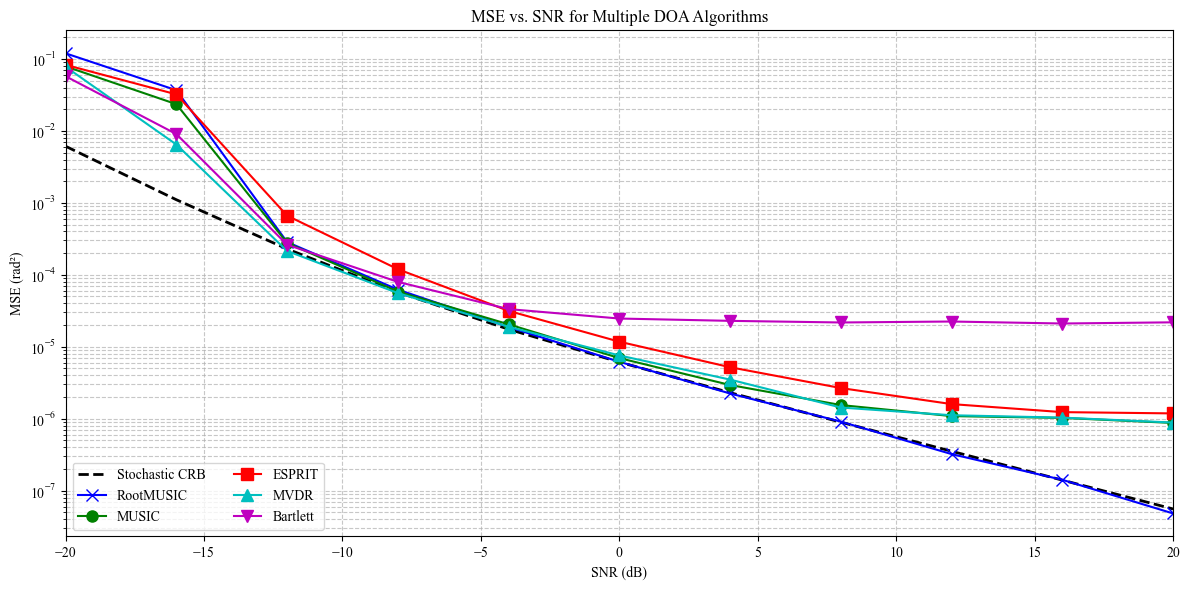

In [4]:
# Plot MSE vs SNR using our plotting tool
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['mse'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='MSE',
    parameter_unit='dB',
    metric_unit='rad²',
    title='MSE vs. SNR for Multiple DOA Algorithms',
    show_crb=True,
    crb_values=crb_snr_values,
    crb_label='Stochastic CRB'
)

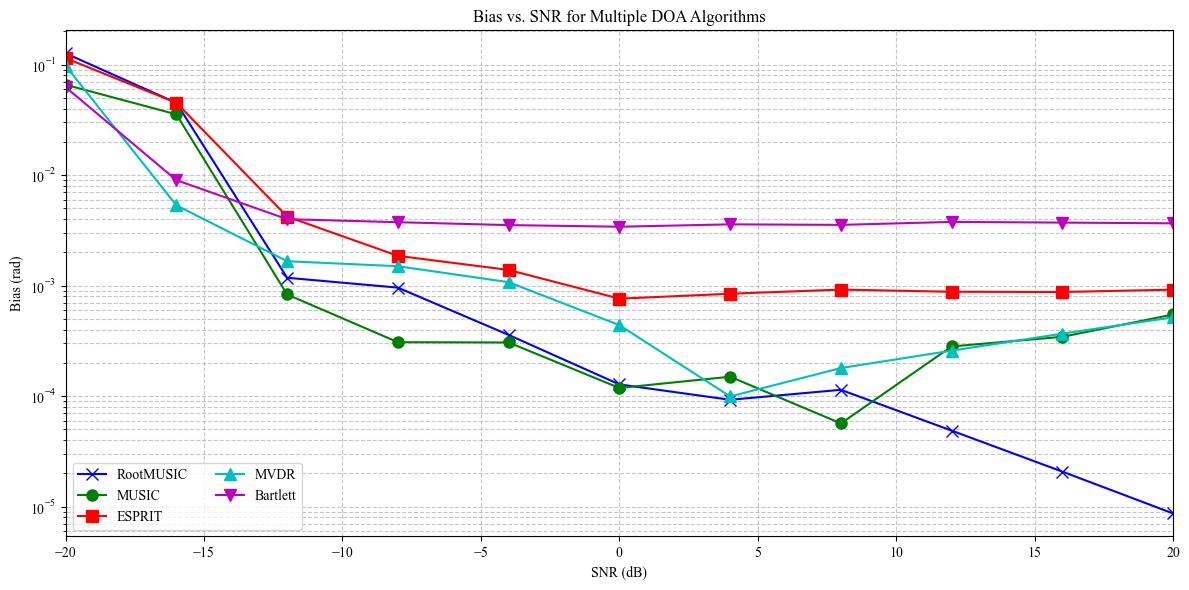

In [5]:
# Plot Bias vs SNR using our plotting tool
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['bias'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='Bias',
    parameter_unit='dB',
    metric_unit='rad',
    title='Bias vs. SNR for Multiple DOA Algorithms'
)

## 3. Performance vs. Number of Snapshots

In [6]:
# Parameters for snapshot test
snapshot_values = np.array([10, 20, 50, 100, 200, 500])  # Number of snapshots
snr_snapshot = 0.0  # SNR in dB for snapshot test

print(f"Running snapshot performance test with {len(snapshot_values)} snapshot points...")

# Initialize results storage
snapshot_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}
crb_snapshot_values = []

# Run simulation for each snapshot count
for n_snap in tqdm(snapshot_values):
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr_snapshot,
        n_snapshots=n_snap,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['sto'],
        metrics=['mse', 'bias']
    )
    
    # Store results
    for alg in estimators.keys():
        snapshot_results[alg]['mse'].append(result.estimator_results[alg]['mse'])
        snapshot_results[alg]['bias'].append(result.estimator_results[alg]['bias'])
    
    # Store CRB values
    crb_snapshot_values.append(result.crb_values['sto'])

# Convert lists to numpy arrays for easier plotting
for alg in snapshot_results.keys():
    snapshot_results[alg]['mse'] = np.array(snapshot_results[alg]['mse'])
    snapshot_results[alg]['bias'] = np.array(snapshot_results[alg]['bias'])

crb_snapshot_values = np.array(crb_snapshot_values)
print("Snapshot performance test completed!")

Running snapshot performance test with 6 snapshot points...


100%|██████████| 6/6 [00:01<00:00,  4.77it/s]

Snapshot performance test completed!


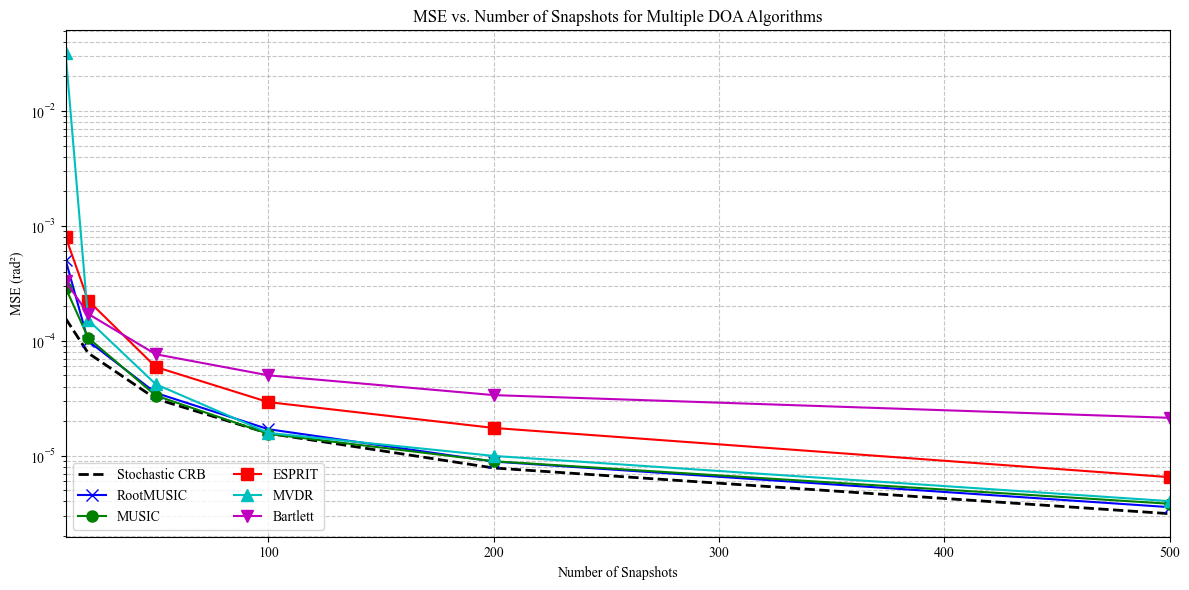

In [7]:
# Plot MSE vs Number of Snapshots using our plotting tool
plt_tools.plot_metric_vs_parameter(
    parameter_values=snapshot_values,
    results={alg: snapshot_results[alg]['mse'] for alg in snapshot_results.keys()},
    parameter_name='Number of Snapshots',
    metric_name='MSE',
    metric_unit='rad²',
    title='MSE vs. Number of Snapshots for Multiple DOA Algorithms',
    show_crb=True,
    crb_values=crb_snapshot_values,
    crb_label='Stochastic CRB'
)

## 4. Resolution Performance vs. Angular Separation

In [8]:
# Parameters for resolution test
delta_thetas_deg = np.linspace(1.0, 10.0, 10)  # Angular separations in degrees
delta_thetas_rad = np.deg2rad(delta_thetas_deg)  # Convert to radians
snr_resolution = 10.0  # SNR in dB for resolution test
n_snapshots_resolution = 200  # Number of snapshots for resolution test

print(f"Running resolution performance test with {len(delta_thetas_deg)} angular separations...")

# Initialize results storage
resolution_results = {alg: {'mse': []} for alg in estimators.keys()}

# Run simulation for each angular separation
for delta_theta in tqdm(delta_thetas_rad):
    # Create sources with current separation
    resolved_sources = model.FarField1DSourcePlacement(
        [-delta_theta/2, delta_theta/2]
    )
    
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=resolved_sources,
        snr=snr_resolution,
        n_snapshots=n_snapshots_resolution,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['sto'],
        metrics=['mse']
    )
    
    # Store results
    for alg in estimators.keys():
        resolution_results[alg]['mse'].append(result.estimator_results[alg]['mse'])

# Convert lists to numpy arrays for easier plotting
for alg in resolution_results.keys():
    resolution_results[alg]['mse'] = np.array(resolution_results[alg]['mse'])

print("Resolution performance test completed!")

Running resolution performance test with 10 angular separations...


100%|██████████| 10/10 [00:02<00:00,  4.49it/s]

Resolution performance test completed!


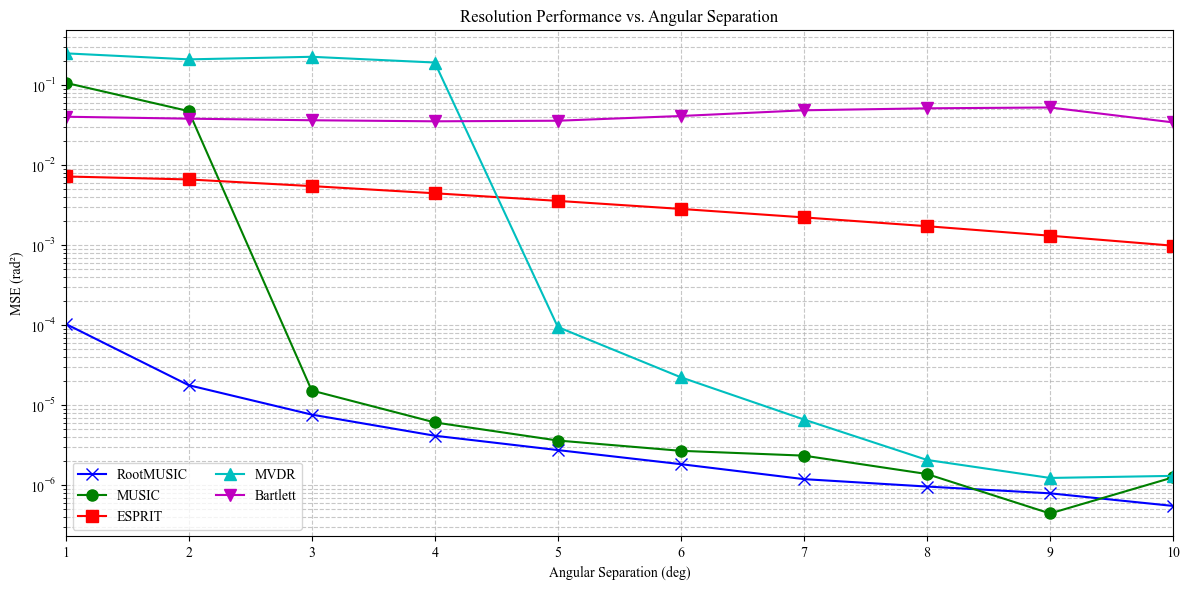

In [9]:
# Plot MSE vs Angular Separation using our plotting tool
plt_tools.plot_metric_vs_parameter(
    parameter_values=delta_thetas_deg,
    results={alg: resolution_results[alg]['mse'] for alg in resolution_results.keys()},
    parameter_name='Angular Separation',
    metric_name='MSE',
    parameter_unit='deg',
    metric_unit='rad²',
    title='Resolution Performance vs. Angular Separation',
    show_crb=False
)

## 5. Additional Visualizations

Generating additional visualizations for RootMUSIC...
Generated 200 valid estimates for visualization


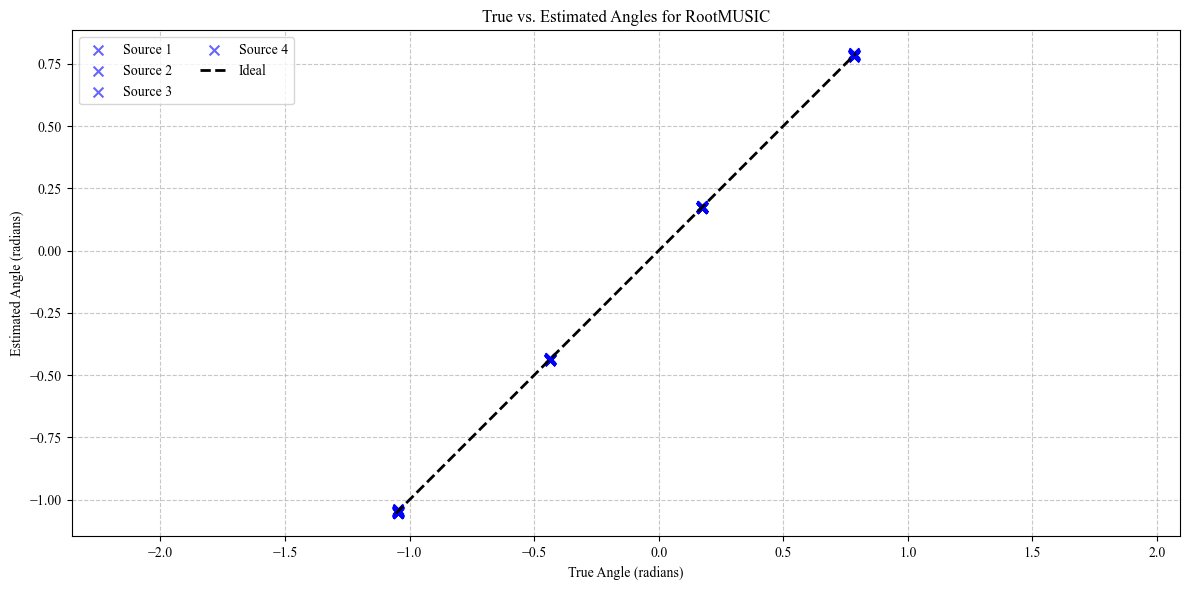

In [10]:
# Let's also generate some additional visualizations for a specific algorithm
# We'll use RootMUSIC at SNR=0 dB with 100 snapshots

print("Generating additional visualizations for RootMUSIC...")

# Generate some sample estimates for visualization
sample_estimates = []
for _ in range(200):  # Generate 200 estimates for visualization
    # Create a simplified simulation
    # Generate signal and noise
    source_signal = np.exp(1j * 2 * np.pi * np.random.rand(n_sources, n_snapshots_snr))
    noise = np.random.randn(array.size, n_snapshots_snr) + 1j * np.random.randn(array.size, n_snapshots_snr)
    noise = noise * np.sqrt(0.5 / 10**(0.0 / 10))  # Noise power based on SNR
    
    # Generate array response
    A = array.steering_matrix(sources, wavelength)
    Y = A @ source_signal + noise
    
    # Compute covariance matrix
    R = Y @ Y.conj().T / n_snapshots_snr
    
    # Get estimates from RootMUSIC
    resolved, est = estimators['RootMUSIC'].estimate(R, n_sources, d0)
    if resolved:
        # Sort estimates to match source order
        est = np.sort(est)
        sample_estimates.append(est)

# Convert to numpy array
sample_estimates = np.array(sample_estimates)
print(f"Generated {sample_estimates.shape[0]} valid estimates for visualization")

# Plot scatter plot of true vs estimated angles
plt_tools.plot_scatter_estimates(
    true_angles=source_angles,
    estimates=sample_estimates,
    algorithm_name='RootMUSIC',
    angle_unit='rad'
)

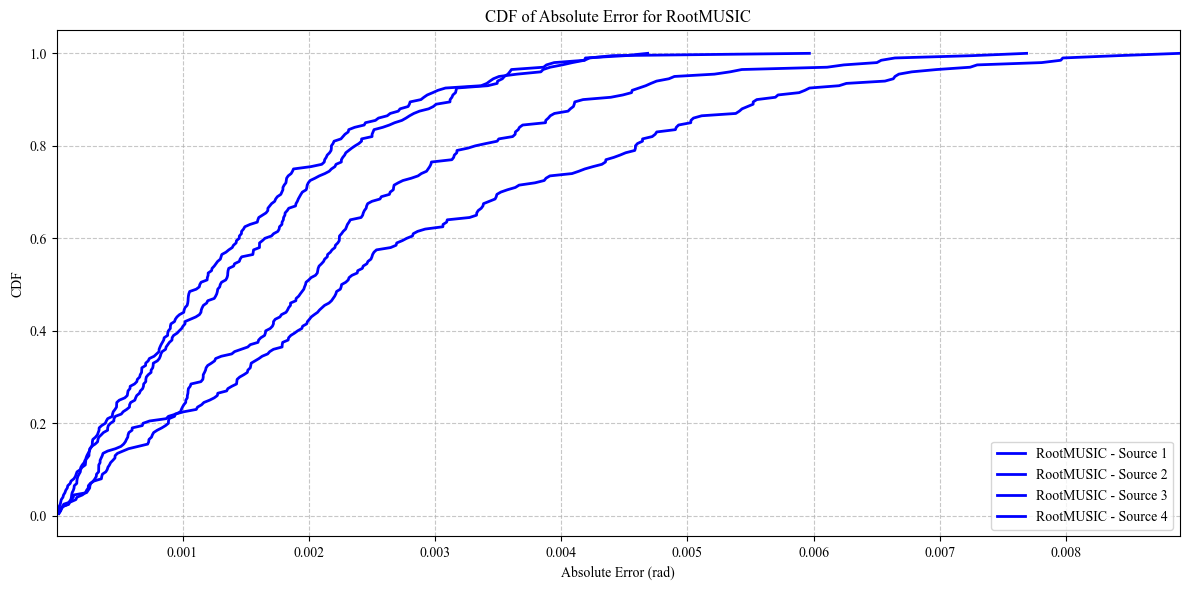

In [11]:
# Plot CDF of estimation errors
plt_tools.plot_cdf(
    estimates=sample_estimates,
    true_angles=source_angles,
    algorithm_name='RootMUSIC',
    metric_name='Absolute Error',
    metric_unit='rad'
)

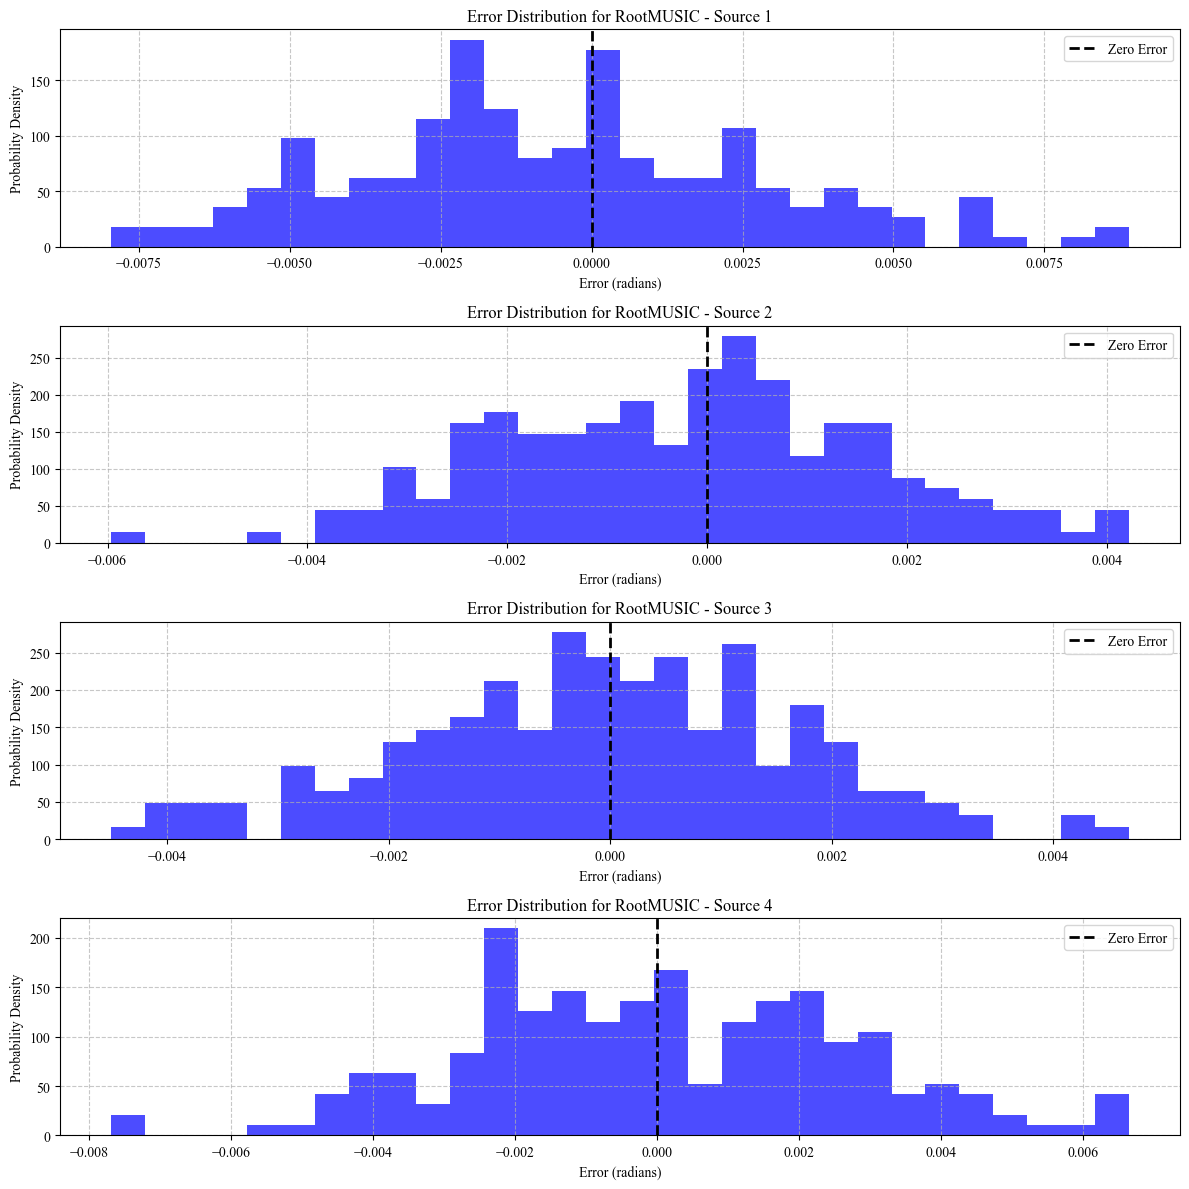

In [12]:
# Plot histogram of estimation errors
plt_tools.plot_histogram(
    estimates=sample_estimates,
    true_angles=source_angles,
    algorithm_name='RootMUSIC',
    bins=30,
    metric_unit='rad'
)

## Summary

This notebook demonstrated the use of our custom DOA performance evaluator and plotting tools to analyze the performance of multiple DOA algorithms under different conditions.

### Key Findings:

1. **SNR Performance**:
   - All algorithms show improved MSE as SNR increases
   - Root-MUSIC and ESPRIT generally perform closest to the CRB
   - Bartlett has the highest MSE across all SNR values
   - Bias decreases with increasing SNR for all algorithms

2. **Snapshot Performance**:
   - Increasing the number of snapshots improves MSE for all algorithms
   - The improvement is more significant for subspace-based methods (Root-MUSIC, MUSIC, ESPRIT)
   - Root-MUSIC and ESPRIT maintain good performance even with fewer snapshots

3. **Resolution Performance**:
   - All algorithms show improved MSE as angular separation increases
   - Root-MUSIC and ESPRIT outperform other algorithms for smaller angular separations
   - Bartlett has the lowest resolution capability
   - MUSIC performs well but is computationally more expensive than Root-MUSIC

### Plotting Tools Used:

- `plot_metric_vs_parameter`: For plotting performance metrics against various parameters
- `plot_scatter_estimates`: For visualizing the relationship between true and estimated angles
- `plot_cdf`: For analyzing the distribution of estimation errors
- `plot_histogram`: For visualizing the probability density of estimation errors

These plotting tools provide a unified and flexible way to visualize DOA performance results, making it easier to compare different algorithms and scenarios.